# Nesting

**What this shows:** how to run a coarse SWAN model over a large area and use its
spectra as the boundary of a finer model near the coast.

**Prerequisites:** [Tutorial 4: Wave boundaries](../tutorial/04_wave_boundaries.ipynb)
and [Tutorial 5: Choosing model settings](../tutorial/05_model_settings.ipynb).

**You will learn:**

- how the parent model writes boundary spectra for a child grid with `NEST`
- how the child model reads them with `BOUNDNEST1`
- how to chain the two runs with rompy

**Data used:** `etopo15s_perth.nc` (bathymetry), `era5-20230101.nc` (winds) and
`ww3-spectra-20230101-short.nc` (boundary spectra for the parent).

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceWavespectra
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_swan.components.cgrid import REGULAR
from rompy_swan.components.group import LOCKUP, OUTPUT, PHYSICS, STARTUP
from rompy_swan.components.lockup import COMPUTE_STAT
from rompy_swan.components.output import BLOCK
from rompy_swan.components.physics import FRICTION_JONSWAP, GEN3, TRIAD
from rompy_swan.components.startup import COORDINATES, MODE, SET
from rompy_swan.config import SwanConfig
from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid
from rompy_swan.interface import DataInterface
from rompy_swan.subcomponents.spectrum import SPECTRUM
from rompy_swan.subcomponents.startup import SPHERICAL

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "nesting"
shutil.rmtree(OUT_DIR, ignore_errors=True)

period = TimeRange(start="2023-01-01T15:00", end="2023-01-01T16:00", interval="1h")

## 1. The two grids

The parent covers the coast from Cape Naturaliste to north of Perth at 0.05°
(about 5 km). The child covers Perth and Rottnest Island at 0.01° (about 1 km), inside
the parent. Both use the same coordinate system, as SWAN requires for nesting.

In [2]:
parent_grid = SwanGrid(x0=114.0, y0=-33.95, dx=0.05, dy=0.05, nx=40, ny=59)
child_grid = SwanGrid(x0=115.3, y0=-32.3, dx=0.01, dy=0.01, nx=51, ny=51)


def swan_config(grid: SwanGrid, boundary, output: OUTPUT) -> SwanConfig:
    """A stationary model at the start of the period, with wind and coastal physics."""
    return SwanConfig(
        startup=STARTUP(
            set=SET(direction_convention="nautical"),
            mode=MODE(kind="nonstationary"),
            coordinates=COORDINATES(kind=SPHERICAL()),
        ),
        cgrid=REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)),
        inpgrid=DataInterface(
            bottom=SwanDataGrid(
                var="bottom",
                source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
                z1="z",
                fac=-1.0,
                coords={"x": "longitude", "y": "latitude"},
                buffer=0.1,
            ),
            input=[
                SwanDataGrid(
                    var="wind",
                    source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
                    z1="u10",
                    z2="v10",
                    coords={"x": "longitude", "y": "latitude"},
                    filter=Filter(sort={"coords": ["latitude"]}),
                    buffer=0.25,
                )
            ],
        ),
        boundary=boundary,
        physics=PHYSICS(gen=GEN3(), friction=FRICTION_JONSWAP(cfjon=0.038), triad=TRIAD()),
        output=output,
        lockup=LOCKUP(compute=COMPUTE_STAT()),
    )

## 2. The parent model

The parent takes its boundary from the WAVEWATCH III spectra. In its output, a `NEST`
combines the child grid (`NGRID`) and the file the spectra are written to
(`NESTOUT`). `OUTPUT.nests` takes a list, so one parent can feed several children.

In [3]:
from rompy_swan.boundary import Boundnest1
from rompy_swan.components.output import NEST, NESTOUT, NGRID
from rompy_swan.interface import BoundaryInterface

parent = swan_config(
    parent_grid,
    boundary=BoundaryInterface(
        kind=Boundnest1(
            id="ww3",
            source=SourceWavespectra(
                uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
            ),
            sel_method="idw",
            sel_method_kwargs={"tolerance": 1.5},
            spacing=0.1,
        )
    ),
    output=OUTPUT(
        block=BLOCK(sname="COMPGRID", fname="swangrid.nc", output=["hsign", "dir"]),
        nests=[
            NEST(
                sname="child",
                ngrid=NGRID(grid=child_grid.component),
                nestout=NESTOUT(fname="child.bnd"),
            )
        ],
    ),
)
print(parent.output.render())

NGRID sname='child' xpn=115.3 ypn=-32.3 alpn=0.0 xlenn=0.5 ylenn=0.5 mxn=50 myn=50

NESTOUT sname='child' fname='child.bnd'

BLOCK sname='COMPGRID' fname='swangrid.nc' &
    HSIGN &
    DIR


## 3. The child model

The child reads the parent's spectra with the `BOUNDNEST1` component, which only
names the file. SWAN interpolates the spectra along the child's boundary.

In [4]:
from rompy_swan.components.boundary import BOUNDNEST1

child = swan_config(
    child_grid,
    boundary=BOUNDNEST1(fname="child.bnd", rectangle="closed"),
    output=OUTPUT(block=BLOCK(sname="COMPGRID", fname="swangrid.nc", output=["hsign", "dir"])),
)
print(child.boundary.render())

BOUNDNEST1 NEST fname='child.bnd' CLOSED


## 4. Running the chain

The parent runs first. Its `child.bnd` is then copied into the child's workspace
before the child runs.

In [5]:
def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
parent_run = ModelRun(run_id="parent", period=period, output_dir=OUT_DIR, config=parent)
child_run = ModelRun(run_id="child", period=period, output_dir=OUT_DIR, config=child)
parent_ws = Path(parent_run())
child_ws = Path(child_run())

if docker_available() and parent_run.run(backend, workspace_dir=parent_ws):
    shutil.copy(parent_ws / "child.bnd", child_ws)
    ok = child_run.run(backend, workspace_dir=child_ws)
    print("Parent and child finished" if ok else "The child run failed")
else:
    print("Docker is not available or the parent failed, skipping the runs")

Parent and child finished


## 5. Results

The child resolves the islands, the reefs and the coast in more detail, with the
waves arriving from the parent along its boundary.

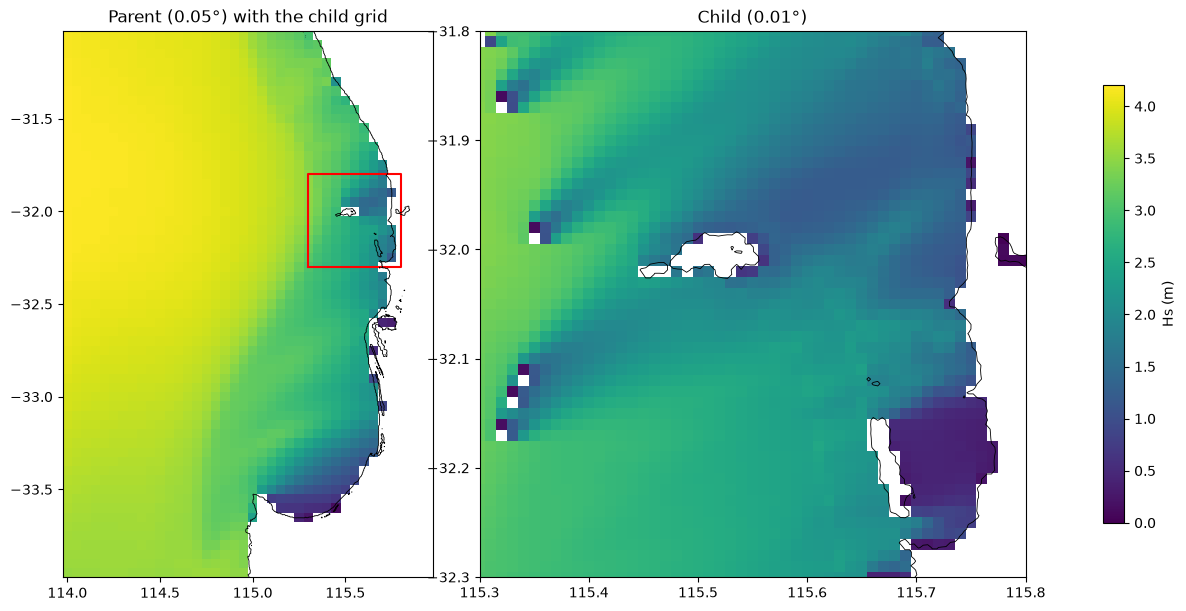

In [6]:
if (child_ws / "swangrid.nc").exists():
    parent_hs = xr.open_dataset(parent_ws / "swangrid.nc").hs.isel(time=0)
    child_hs = xr.open_dataset(child_ws / "swangrid.nc").hs.isel(time=0)
    etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
    x0, y0, x1, y1 = child_grid.bbox()
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), layout="constrained")
    parent_hs.plot(ax=axes[0], cmap="viridis", vmin=0, vmax=4.2, add_colorbar=False)
    axes[0].plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "r")
    pm = child_hs.plot(ax=axes[1], cmap="viridis", vmin=0, vmax=4.2, add_colorbar=False)
    for ax, title in zip(axes, ["Parent (0.05°) with the child grid", "Child (0.01°)"]):
        etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
        ax.set(title=title, xlabel="", ylabel="")
        ax.set_aspect("equal")
    axes[0].set_xticks([114.0, 114.5, 115.0, 115.5])
    axes[1].set(xlim=(x0, x1), ylim=(y0, y1))
    fig.colorbar(pm, ax=axes, label="Hs (m)", shrink=0.8)

## Summary

- The parent writes spectra for a child grid with `OUTPUT.nests` (`NEST` = `NGRID` +
  `NESTOUT`).
- The child reads them with `BOUNDNEST1`; copy the file into its workspace.
- Parent and child must use the same coordinate system and cover the same period.